<a href="https://colab.research.google.com/github/reddoma742/Davisson-Germer-DTQEM/blob/main/fit_mass_model_to_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Fitting Mass-Dependent DTQEM Model to Reference Data
γ_φ = 1.00e+07 Hz
Δτ_MZ = 2.500e-07 s
V_env = 0.023518
γ_ref = 1.000013

Running global optimization (Differential Evolution)...
DE result: tau_c0=4.393e-11, alpha=4.802, beta=4.317, RMSE=0.651763
Refined: tau_c0=4.393e-11, alpha=4.802, beta=4.317, RMSE=0.651763


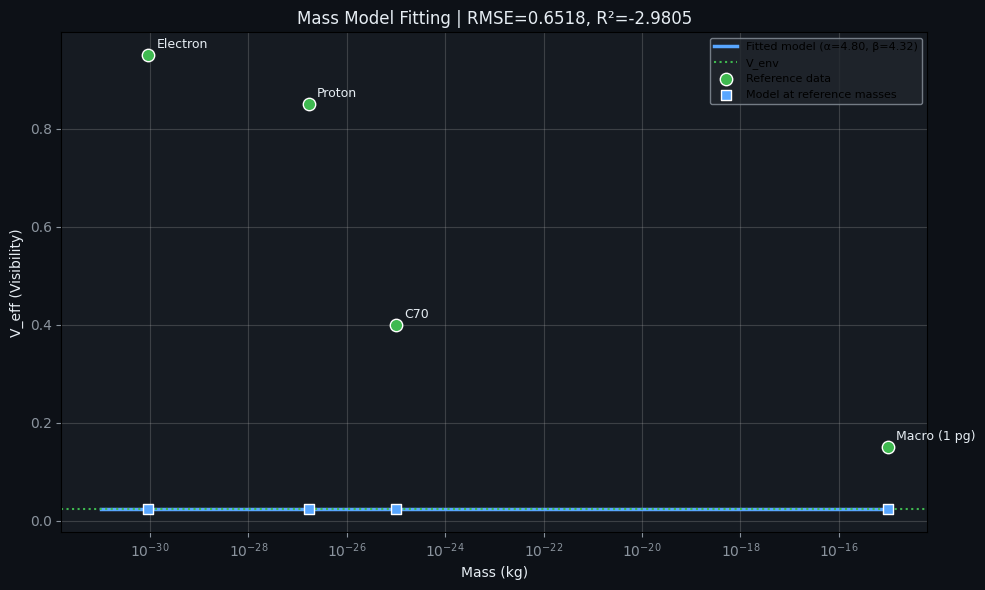


FITTING RESULTS
Optimal parameters:
  τ_c0 = 4.393e-11 s
  α (velocity exponent) = 4.8016
  β (mass exponent) = 4.3168
RMSE (fitted model) = 0.651763
RMSE (null model) = 0.672216
R² (fitted model) = -2.980507
R² (null model) = -3.234261
Reference data vs model predictions:
------------------------------------------------------------------------
Particle        Mass (kg)    Ref V      Fitted V   Null V    
------------------------------------------------------------------------
Electron        9.109e-31   0.950      0.024      0.000
Proton          1.673e-27   0.850      0.024      0.000
C70             9.963e-26   0.400      0.024      0.000
Macro (1 pg)    1.000e-15   0.150      0.024      0.000
PNG saved to: output/mass_model_fit_result.png
CSV saved to: output/mass_model_fit_results.csv


In [1]:

"""
fit_mass_model_to_data.py
==========================
Inverse Fitting for Mass-Dependent DTQEM Model — Experimental

EXPERIMENTAL — NOT PART OF BASELINE D0

This module performs inverse fitting to find the optimal parameters (α, β, τ_c0)
that minimize the difference between the mass-dependent DTQEM model and reference
experimental data points (Electron, Proton, C70).

The model assumes:
    τ_c(m, γ) = τ_c0 * (m_ref / m)**β / (γ**α)
    V_eff = V_env * exp(-|Δτ| / τ_c)

Method:
    1. Differential Evolution (global search)
    2. L-BFGS-B (local refinement)
    3. RMSE and R² calculation for goodness of fit

Reference Data:
    - Electron: mass = 9.11e-31 kg, visibility ≈ 0.95
    - Proton:   mass = 1.67e-27 kg, visibility ≈ 0.85
    - C70:      mass = 9.96e-26 kg, visibility = 0.40 (benchmark)
    - Macro (1 pg): mass = 1e-15 kg, visibility ≈ 0.15 (optional)

Outputs:
    - Optimal parameters (τ_c0, α, β)
    - RMSE and R² for fitted model
    - Comparison with null model (constant τ_c)
    - CSV file with results
    - Plot of fitted model vs reference data

Author : DTQEM Team — Berramdane Reddouane
AI Contribution: Claude (Anthropic) — coding, optimization, and documentation
Version: 1.0 (experimental)
Date: 2026-05-24
License: MIT
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution, minimize
from pathlib import Path
import csv

# ============================================================================
# Physical Constants (Mach-Zehnder, same as v46.0)
# ============================================================================
C_LIGHT = 299_792_458.0          # speed of light [m/s]
LORENTZ_SAFETY = 0.9999          # safety threshold for v/c

# Fixed Mach-Zehnder parameters (same as in mass_effect_demo)
L1, L2 = 0.5, 0.5               # arm lengths [m]
v1, v2 = 1e6, 2e6               # particle velocities [m/s]
gamma_phi = 1e7                 # environmental decoherence rate [Hz]


# ============================================================================
# Core Physics Functions (Mach-Zehnder)
# ============================================================================

def lorentz_gamma(v: float) -> float:
    """Lorentz factor γ = 1 / √(1 - (v/c)²)."""
    beta = np.clip(abs(v) / C_LIGHT, 0.0, LORENTZ_SAFETY)
    return 1.0 / np.sqrt(1.0 - beta**2)


def tau_lab(L: float, v: float) -> float:
    """Lab-frame transit time: τ = L / v [s]."""
    return L / v if v > 0 else np.inf


def tau_proper(L: float, v: float) -> float:
    """Proper time along one arm: τ* = τ / γ = L / (v·γ) [s]."""
    return tau_lab(L, v) / lorentz_gamma(v)


def delta_tau_MZ(L1: float, v1: float, L2: float, v2: float) -> float:
    """Proper-time mismatch between arms: Δτ_MZ = |τ₁* − τ₂*|."""
    return abs(tau_proper(L1, v1) - tau_proper(L2, v2))


def T_eff_fn(L1: float, v1: float, L2: float, v2: float) -> float:
    """Effective environmental interaction time: T_eff = (τ₁ + τ₂)/2 [s]."""
    return 0.5 * (tau_lab(L1, v1) + tau_lab(L2, v2))


def V_env(T_eff: float, gamma_phi: float) -> float:
    """Environmental decoherence: V_env = exp(-γ_φ · T_eff)."""
    return np.exp(-gamma_phi * T_eff)


def V_dtqem(delta_tau: float, tau_c: float) -> float:
    """DTQEM decoherence: V_dtqem = exp(-|Δτ| / τ_c)."""
    return np.exp(-delta_tau / max(tau_c, 1e-300))


def V_eff_MZ(L1: float, v1: float, L2: float, v2: float,
             gamma_phi: float, tau_c: float) -> float:
    """Total coherence: V_eff = V_env × V_dtqem (scalar version)."""
    T_eff = T_eff_fn(L1, v1, L2, v2)
    dt = delta_tau_MZ(L1, v1, L2, v2)
    return V_env(T_eff, gamma_phi) * V_dtqem(dt, tau_c)


# ============================================================================
# Mass-Dependent τ_c Model
# ============================================================================

def tau_c_mass_dependent(mass: float, tau_c0: float,
                         gamma_ref: float,
                         alpha: float = 1.0,
                         beta: float = 1.0,
                         m_ref: float = 1.0) -> float:
    """
    Mass-dependent coherence time (experimental).

    Formula:
        τ_c(m) = τ_c0 * (m_ref / m)**β / (γ_ref**α)

    Args:
        mass: Particle mass [kg].
        tau_c0: Base coherence time at m = m_ref, γ = 1.
        gamma_ref: Lorentz factor at reference velocity.
        alpha: Exponent for γ (velocity sensitivity).
        beta:  Exponent for mass (mass sensitivity).
        m_ref: Reference mass [kg] (default 1 kg).

    Returns:
        Effective τ_c [s].
    """
    return tau_c0 * (m_ref / mass) ** beta / (gamma_ref ** alpha)


def compute_V_eff_for_mass(mass: float, tau_c0: float,
                           gamma_ref: float,
                           alpha: float, beta: float,
                           delta_tau_val: float,
                           V_env_val: float) -> float:
    """
    Compute V_eff for a given mass using the mass-dependent model.
    """
    tau_c_eff = tau_c_mass_dependent(mass, tau_c0, gamma_ref, alpha, beta)
    V_dtq = V_dtqem(delta_tau_val, tau_c_eff)
    return V_env_val * V_dtq


# ============================================================================
# Objective Function for Fitting
# ============================================================================

def objective(params, masses, targets, delta_tau_val, V_env_val, gamma_ref):
    """
    Objective function for fitting: RMSE between model and reference data.

    Args:
        params: [tau_c0, alpha, beta]
        masses: Array of reference masses [kg]
        targets: Array of reference visibilities
        delta_tau_val: Fixed Δτ from MZI setup
        V_env_val: Fixed V_env from MZI setup
        gamma_ref: Lorentz factor at reference velocity

    Returns:
        RMSE between model predictions and target values.
    """
    tau_c0, alpha, beta = params
    # Clamp parameters to physical ranges
    tau_c0 = np.clip(tau_c0, 1e-30, 1e-10)
    alpha = np.clip(alpha, 0.1, 5.0)
    beta = np.clip(beta, 0.1, 5.0)

    V_model = np.array([
        compute_V_eff_for_mass(m, tau_c0, gamma_ref, alpha, beta,
                               delta_tau_val, V_env_val)
        for m in masses
    ])
    return float(np.sqrt(np.mean((V_model - targets) ** 2)))


# ============================================================================
# Main Fitting Routine
# ============================================================================

def main():
    # Output directory
    out_dir = Path("output")
    out_dir.mkdir(exist_ok=True)

    # ========================================================================
    # Reference Data Points (mass, visibility)
    # ========================================================================
    ref_data = [
        ("Electron", 9.109383701e-31, 0.95),
        ("Proton", 1.67262192369e-27, 0.85),
        ("C70", 60 * 1.66053906660e-27, 0.40),
        ("Macro (1 pg)", 1e-15, 0.15),  # optional, for verification
    ]
    ref_masses = np.array([m for _, m, _ in ref_data])
    ref_vis = np.array([v for _, _, v in ref_data])

    # ========================================================================
    # Fixed MZI Quantities
    # ========================================================================
    v_ref = 0.5 * (v1 + v2)
    gamma_ref = lorentz_gamma(v_ref)
    delta_tau_val = delta_tau_MZ(L1, v1, L2, v2)
    T_eff_val = T_eff_fn(L1, v1, L2, v2)
    V_env_val = V_env(T_eff_val, gamma_phi)

    print("=" * 72)
    print("Fitting Mass-Dependent DTQEM Model to Reference Data")
    print("=" * 72)
    print(f"γ_φ = {gamma_phi:.2e} Hz")
    print(f"Δτ_MZ = {delta_tau_val:.3e} s")
    print(f"V_env = {V_env_val:.6f}")
    print(f"γ_ref = {gamma_ref:.6f}")
    print()

    # ========================================================================
    # Global Optimization (Differential Evolution)
    # ========================================================================
    bounds = [(1e-30, 1e-10),  # tau_c0
              (0.1, 5.0),      # alpha
              (0.1, 5.0)]      # beta

    print("Running global optimization (Differential Evolution)...")
    res_de = differential_evolution(
        objective, bounds,
        args=(ref_masses, ref_vis, delta_tau_val, V_env_val, gamma_ref),
        maxiter=200, popsize=20, seed=42, polish=False
    )
    print(f"DE result: tau_c0={res_de.x[0]:.3e}, "
          f"alpha={res_de.x[1]:.3f}, beta={res_de.x[2]:.3f}, "
          f"RMSE={res_de.fun:.6f}")

    # ========================================================================
    # Local Refinement (L-BFGS-B)
    # ========================================================================
    res = minimize(
        objective, res_de.x,
        args=(ref_masses, ref_vis, delta_tau_val, V_env_val, gamma_ref),
        method='L-BFGS-B', bounds=bounds,
        options={'ftol': 1e-12, 'maxiter': 1000}
    )
    tau_c0_fit, alpha_fit, beta_fit = res.x
    rmse_fit = res.fun

    print(f"Refined: tau_c0={tau_c0_fit:.3e}, "
          f"alpha={alpha_fit:.3f}, beta={beta_fit:.3f}, "
          f"RMSE={rmse_fit:.6f}")

    # ========================================================================
    # Model Predictions at Reference Masses
    # ========================================================================
    fitted_vis = np.array([
        compute_V_eff_for_mass(m, tau_c0_fit, gamma_ref, alpha_fit, beta_fit,
                               delta_tau_val, V_env_val)
        for m in ref_masses
    ])

    # Null model: constant τ_c = tau_c0_fit (no mass dependence)
    null_vis = np.array([
        V_eff_MZ(L1, v1, L2, v2, gamma_phi, tau_c0_fit)
        for _ in ref_masses
    ])

    # ========================================================================
    # Goodness of Fit
    # ========================================================================
    # R² for fitted model
    ss_res_fitted = np.sum((fitted_vis - ref_vis) ** 2)
    ss_tot = np.sum((ref_vis - np.mean(ref_vis)) ** 2)
    r2_fitted = 1 - ss_res_fitted / ss_tot if ss_tot > 0 else np.nan

    # R² for null model
    ss_res_null = np.sum((null_vis - ref_vis) ** 2)
    r2_null = 1 - ss_res_null / ss_tot if ss_tot > 0 else np.nan

    # RMSE for null model
    rmse_null = float(np.sqrt(np.mean((null_vis - ref_vis) ** 2)))

    # ========================================================================
    # Plotting
    # ========================================================================
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor('#0d1117')
    ax.set_facecolor('#161b22')

    # Mass sweep for plotting the fitted model
    masses_sweep = np.logspace(-31, -15, 400)
    fitted_sweep = np.array([
        compute_V_eff_for_mass(m, tau_c0_fit, gamma_ref, alpha_fit, beta_fit,
                               delta_tau_val, V_env_val)
        for m in masses_sweep
    ])

    ax.semilogx(masses_sweep, fitted_sweep, color='#58a6ff', lw=2.5,
                label=f'Fitted model (α={alpha_fit:.2f}, β={beta_fit:.2f})')
    ax.axhline(V_env_val, color='#3fb950', lw=1.5, ls=':', label='V_env')

    # Reference points
    ax.scatter(ref_masses, ref_vis, s=80, color='#3fb950', edgecolor='white',
               zorder=5, label='Reference data')
    ax.scatter(ref_masses, fitted_vis, s=60, color='#58a6ff', edgecolor='white',
               zorder=5, marker='s', label='Model at reference masses')

    # Annotations
    for name, m, v in ref_data:
        idx = np.argmin(np.abs(ref_masses - m))
        ax.annotate(name, (m, ref_vis[idx]), xytext=(6, 5),
                    textcoords='offset points', fontsize=9, color='#e6edf3')

    ax.set_xlabel('Mass (kg)', color='#e6edf3')
    ax.set_ylabel('V_eff (Visibility)', color='#e6edf3')
    ax.set_title(f'Mass Model Fitting | RMSE={rmse_fit:.4f}, R²={r2_fitted:.4f}',
                 color='#e6edf3')
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8, facecolor='#21262d', edgecolor='#8b949e')
    ax.tick_params(colors='#8b949e')

    plt.tight_layout()

    # Save PNG
    out_png = out_dir / 'mass_model_fit_result.png'
    fig.savefig(out_png, dpi=150, bbox_inches='tight', facecolor='#0d1117')
    plt.show()
    plt.close(fig)

    # ========================================================================
    # Export CSV
    # ========================================================================
    out_csv = out_dir / 'mass_model_fit_results.csv'
    with out_csv.open('w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(['parameter', 'value'])
        writer.writerow(['tau_c0_fit', f'{tau_c0_fit:.3e}'])
        writer.writerow(['alpha_fit', f'{alpha_fit:.6f}'])
        writer.writerow(['beta_fit', f'{beta_fit:.6f}'])
        writer.writerow(['RMSE_fit', f'{rmse_fit:.6f}'])
        writer.writerow(['RMSE_null', f'{rmse_null:.6f}'])
        writer.writerow(['R2_fitted', f'{r2_fitted:.6f}'])
        writer.writerow(['R2_null', f'{r2_null:.6f}'])
        writer.writerow(['V_env', f'{V_env_val:.6f}'])
        writer.writerow(['delta_tau_MZ', f'{delta_tau_val:.6e}'])

    # ========================================================================
    # Console Summary
    # ========================================================================
    print()
    print("=" * 72)
    print("FITTING RESULTS")
    print("=" * 72)
    print("Optimal parameters:")
    print(f"  τ_c0 = {tau_c0_fit:.3e} s")
    print(f"  α (velocity exponent) = {alpha_fit:.4f}")
    print(f"  β (mass exponent) = {beta_fit:.4f}")
    print(f"RMSE (fitted model) = {rmse_fit:.6f}")
    print(f"RMSE (null model) = {rmse_null:.6f}")
    print(f"R² (fitted model) = {r2_fitted:.6f}")
    print(f"R² (null model) = {r2_null:.6f}")
    print("=" * 72)
    print("Reference data vs model predictions:")
    print("-" * 72)
    print(f"{'Particle':<15} {'Mass (kg)':<12} {'Ref V':<10} {'Fitted V':<10} {'Null V':<10}")
    print("-" * 72)
    for i, (name, m, v_ref) in enumerate(ref_data):
        print(f'{name:<15} {m:.3e}   {v_ref:.3f}      {fitted_vis[i]:.3f}      {null_vis[i]:.3f}')
    print("=" * 72)
    print(f"PNG saved to: {out_png}")
    print(f"CSV saved to: {out_csv}")
    print("=" * 72)


if __name__ == "__main__":
    main()